In [ ]:
!pip install qiskit
!pip install qiskit_aer
!pip install pylatexenc
!pip install qiskit_ibm_provider
!pip install qiskit_ibm_runtime
from qiskit import *
from qiskit_aer import *
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from qiskit.compiler import *
from qiskit.visualization import *
from qiskit.quantum_info import *
from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit import QuantumCircuit
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit_ibm_runtime import Sampler
import matplotlib.pyplot as plt
from qiskit.visualization import plot_histogram
from qiskit.result import marginal_counts
import numpy as np

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.5/6.5 MB 65.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 119.7/119.7 kB 11.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 78.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.5/49.5 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.7/49.7 MB 18.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 109.0/109.0 kB 9.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 106.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 4.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for pylatexenc: filename=pylatexenc-2.10-py3-none-any.whl size=136817 sha256=fcb6983a8d7c09860801c3a28ebc45cb55b8eb0ec3aa0361d79ac2d93e9cd08b
  Stored in directory: /root/.cache/pip/wheels/b1/7a/33/9fdd892f784ed4afda62b685ae3703adf4c91aa0f524c28f03
Successfully built pylatexenc
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [ ]:
!git clone https://github.com/SRI-International/QC-App-Oriented-Benchmarks.git

Cloning into 'QC-App-Oriented-Benchmarks'...
remote: Enumerating objects: 11088, done.
remote: Counting objects: 100% (991/991), done.
remote: Compressing objects: 100% (248/248), done.
remote: Total 11088 (delta 797), reused 765 (delta 741), pack-reused 10097 (from 3)
Receiving objects: 100% (11088/11088), 130.76 MiB | 15.75 MiB/s, done.
Resolving deltas: 100% (6563/6563), done.


In [ ]:
# Grover’s Search
%cd QC-App-Oriented-Benchmarks/grovers/qiskit

/content/QC-App-Oriented-Benchmarks/grovers/qiskit


[Errno 2] No such file or directory: 'QC-App-Oriented-Benchmarks/grovers/qiskit'
/content/QC-App-Oriented-Benchmarks/grovers/qiskit
Grover's Search Benchmark Program - Qiskit
... execution starting at Apr 25, 2025 02:09:14 UTC
************
Executing [3] circuits with num_qubits = 2


/usr/local/lib/python3.11/dist-packages/qiskit/compiler/transpiler.py:269: UserWarning: Providing `coupling_map` and/or `basis_gates` along with `backend` is not recommended, as this will invalidate the backend's gate durations and error rates.
  pm = generate_preset_pass_manager(


************
Executing [3] circuits with num_qubits = 3
************
Average Circuit Algorithmic Depth, ξ (xi) for the 2 qubit group = 13, 0.118
Average Normalized Transpiled Depth, ξ (xi), 2q gates for the 2 qubit group = 12, 0.129, 2.0
Average Creation, Elapsed, Execution Time for the 2 qubit group = 0.003, 0.343, 0.004 secs
Average Transpiling, Validating, Running Times for group 2 = 0.001, 0.001, 0.001 secs
Average Hellinger, Normalized Fidelity for the 2 qubit group = 0.991, 0.988

************
Executing [3] circuits with num_qubits = 4
************
Executing [3] circuits with num_qubits = 5
************
Executing [3] circuits with num_qubits = 6
************
Average Circuit Algorithmic Depth, ξ (xi) for the 3 qubit group = 25, 0.088
Average Normalized Transpiled Depth, ξ (xi), 2q gates for the 3 qubit group = 51, 0.313, 24.0
Average Creation, Elapsed, Execution Time for the 3 qubit group = 0.004, 1.895, 0.01 secs
Average Transpiling, Validating, Running Times for group 3 = 0.001,

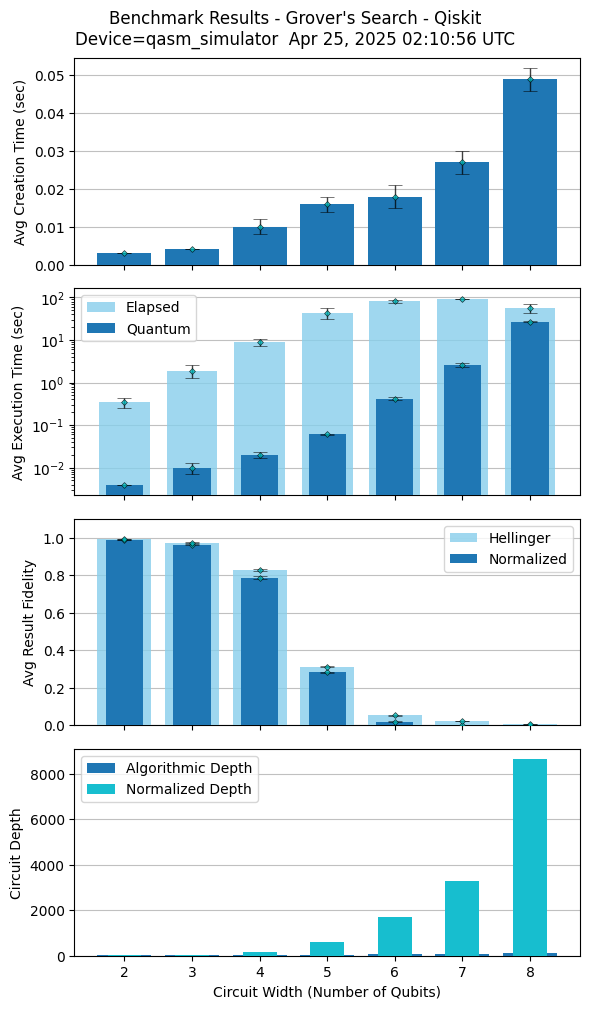

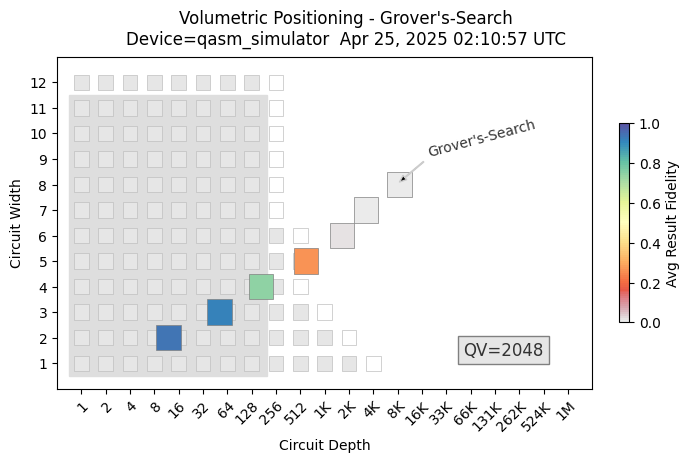

In [ ]:
# 1) Se placer dans le dossier Grover
%cd QC-App-Oriented-Benchmarks/grovers/qiskit

# 2) Choisir le backend simulateur AER
simulator = Aer.get_backend('aer_simulator')

# 3) Couper le flood stevedore (facultatif)
import logging, warnings, sys
logging.getLogger('stevedore.extension').setLevel(logging.CRITICAL)

# 4) Importer le benchmark Grover
import grovers_benchmark as gb   # <-- différent de qft_benchmark

# 5) Lancer le benchmark
gb.run(
    min_qubits = 2,      # taille mini
    max_qubits = 8,      # taille maxi (le script limite de toute façon à 8)
    skip_qubits = 1,     # incrément
    max_circuits = 3,    # instances aléatoires par taille
    num_shots = 1024,    # tirs par circuit
    use_mcx_shim = False,   # True si vous voulez remplacer les MCX par un shim (utile sur HW)
    backend_id = 'qasm_simulator'  # on pointe vers Aer
)

Répertoire courant AVANT changement: /content/QC-App-Oriented-Benchmarks/grovers/qiskit
Déjà dans le bon répertoire: /content/QC-App-Oriented-Benchmarks/grovers/qiskit
Using backend: ibm_sherbrooke
Backend basis gates: ['ecr', 'id', 'rz', 'sx', 'x']
... execution starting at Apr 25, 2025 03:07:45 UTC

Generating circuits for 2 to 6 qubits (Grover's Search)...
... 2 qubits
    (Using n_iterations = 1)
... 3 qubits
    (Using n_iterations = 2)
... 4 qubits
    (Using n_iterations = 3)
... 5 qubits
    (Using n_iterations = 4)
... 6 qubits
    (Using n_iterations = 6)

Generated 15 circuits in 0.25s.

Transpiling 15 circuits for ibm_sherbrooke...
Attempting transpilation with optimization_level=1...
Transpilation finished in 3.35s.

Submitting 15 transpiled circuits...
Job submitted: d05fs246rr3g008egcd0
Waiting for results...
Job finished in 48.08s.

Analyzing 15 results...
Total quantum execution time (reported by IBM): 11.0000s

Finalizing metric groups (for internal state)...
********

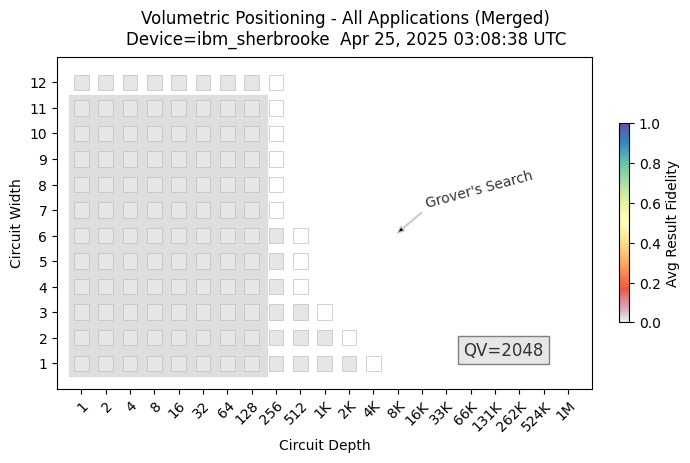

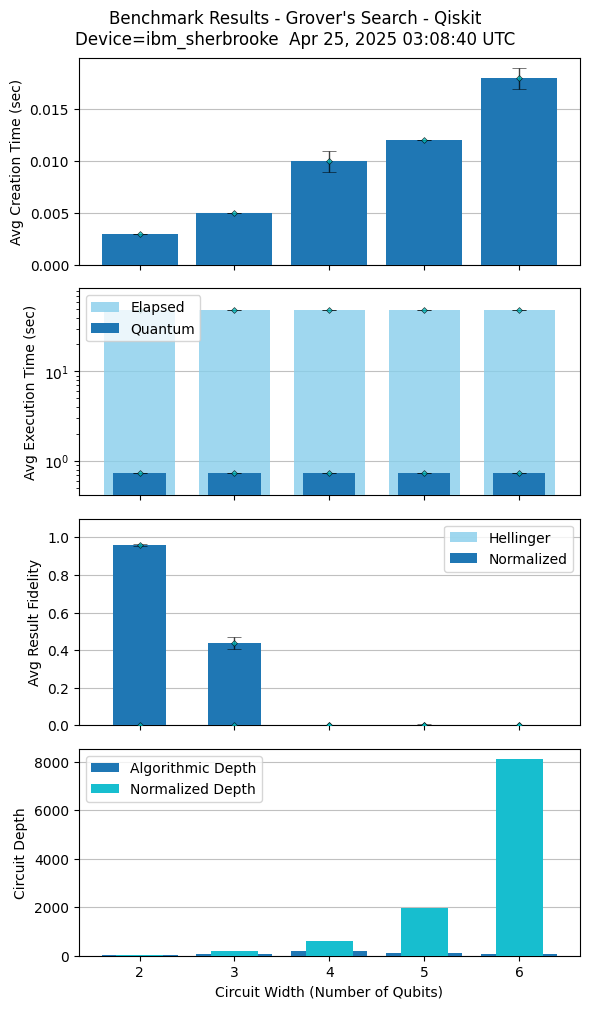

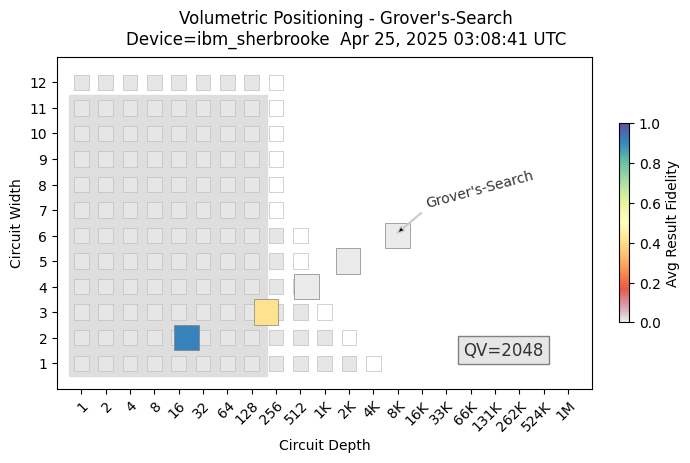


Plots potentially generated!
Check for image files like '_ALL-vplot-2*.png' and 'Benchmark Results - Grover's Search - Qiskit*.png'
Or check for inline plots.

Execution finished.


In [ ]:
# --- Imports ---
import sys
import time
import math
import numpy as np
import warnings
import os
import traceback
import json # Pour sauvegarder/charger les métriques

# Matplotlib pour les graphiques (requis par metrics.py)
import matplotlib.pyplot as plt

# --- 1) Se placer dans le dossier Grover ---
print(f"Répertoire courant AVANT changement: {os.getcwd()}")
try:
    base_path = "/content/QC-App-Oriented-Benchmarks"
    # *** Utiliser VOTRE nom de dossier 'grovers' ***
    target_dir = os.path.join(base_path, "grovers/qiskit")
    # ***********************************************
    if os.path.exists(target_dir):
        if os.getcwd() != os.path.abspath(target_dir):
             os.chdir(target_dir); print(f"Nouveau répertoire courant: {os.getcwd()}")
        else: print(f"Déjà dans le bon répertoire: {os.getcwd()}")
    else: print(f"ERREUR: Répertoire cible inexistant: {target_dir}"); sys.exit(1)
except Exception as e: print(f"Erreur changement de répertoire: {e}"); sys.exit(1)

# Qiskit imports
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit_ibm_runtime import QiskitRuntimeService, Sampler
from qiskit.compiler import transpile

# --- Importer les modules et fonctions du benchmark ---
try:
    import metrics as metrics
    # *** Importer depuis grovers_kernel ***
    from grovers_kernel import GroversSearch
    # *************************************
    from metrics import polarization_fidelity, finalize_group
    from metrics import plot_all_app_metrics, store_app_metrics # Utiliser ces fonctions
except ImportError as e:
    print(f"Erreur importation modules benchmark: {e}")
    print("Assurez-vous que 'grovers_kernel.py' et le dossier _common sont accessibles.")
    sys.exit(1)

# --- Configuration Qiskit Runtime ---
warnings.filterwarnings('ignore', category=DeprecationWarning)
try:
    # REMPLACEZ "VOTRE_TOKEN_API_ICI" SI NÉCESSAIRE
    service = QiskitRuntimeService( channel="ibm_quantum", instance="ibm-q/open/main", token="5fbbdfd71d575ba3bcc1a1fc39c96ec43556b3c5c4030bae8adb36345780c9f5bc622a0f07f6a48c7603db47d5dc61e01e4557bb49c07708811babe912d70147")
    backend = service.backend("ibm_sherbrooke")
    print(f"Using backend: {backend.name}"); print(f"Backend basis gates: {backend.basis_gates}")
except Exception as e: print(f"Erreur connexion IBM Quantum: {e}"); sys.exit(1)

# --- Initialisation des Métriques ---
metrics.init_metrics()
# Définir les informations nécessaires pour store_app_metrics et plot_all_app_metrics
metrics.circuit_metrics['subtitle'] = f"Device={backend.name}"
metrics.circuit_metrics['backend_id'] = backend.name
benchmark_name = "Grover's Search"; method = None; api_name = "Qiskit"
# Ce titre sera utilisé comme clé dans le fichier JSON et pour les graphiques
app_title = f"Benchmark Results - {benchmark_name} - {api_name}"

# --- Paramètres du Benchmark ---
min_qubits=2; max_qubits=6; skip_qubits=1; max_circuits=3; num_shots=1024
use_mcx_shim_in_kernel = False

# --- Boucle de Génération ---
circuits_info = []
print(f"\nGenerating circuits for {min_qubits} to {max_qubits} qubits ({benchmark_name})...")
generation_start_time = time.time(); metrics.start_time = generation_start_time # Nécessaire pour store_app_metrics
for num_qubits in range(min_qubits, max_qubits + 1, skip_qubits):
    input_size = num_qubits; print(f"... {num_qubits} qubits")
    num_circuits_for_size = min(2**input_size, max_circuits)
    np.random.seed(0)
    possible_s_ints = list(range(2**input_size))
    if len(possible_s_ints) <= num_circuits_for_size: s_range = possible_s_ints
    else: s_range = np.random.choice(possible_s_ints, size=num_circuits_for_size, replace=False)

    n_iterations = 1
    if num_qubits > 0: n_iterations = max(1, int(np.pi * np.sqrt(2 ** num_qubits) / 4))
    print(f"    (Using n_iterations = {n_iterations})")

    for s_int in s_range:
        s_int = int(s_int); ts = time.time()
        try:
            qc = GroversSearch(num_qubits, s_int, n_iterations, use_mcx_shim_in_kernel)
            if not isinstance(qc, QuantumCircuit): continue
            creation_time = time.time() - ts
        except Exception as e_gen: print(f"Erreur génération circuit Grover: {e_gen}"); continue

        metrics.store_metric(input_size, s_int, 'create_time', creation_time)
        qc_decomposed = qc.decompose()
        circuits_info.append({"circuit_decomposed": qc_decomposed, "num_qubits": num_qubits, "s_int": s_int})
print(f"\nGenerated {len(circuits_info)} circuits in {time.time() - generation_start_time:.2f}s.")

if not circuits_info: print("\nAucun circuit généré. Arrêt."); sys.exit(1)
all_circuits_decomposed = [info["circuit_decomposed"] for info in circuits_info]

# --- TRANSPILATION EXPLICITE ---
print(f"\nTranspiling {len(all_circuits_decomposed)} circuits for {backend.name}...")
transpilation_start_time = time.time(); transpiled_circuits = None
try:
    opt_level = 1; print(f"Attempting transpilation with optimization_level={opt_level}...")
    transpiled_circuits = transpile(all_circuits_decomposed, backend=backend, optimization_level=opt_level)
    print(f"Transpilation finished in {time.time() - transpilation_start_time:.2f}s.")
except Exception as e: print(f"Erreur transpilation: {e}")

# --- Exécution avec Sampler ---
job = None; result = None; execution_finish_time = time.time()
if transpiled_circuits:
    print(f"\nSubmitting {len(transpiled_circuits)} transpiled circuits...")
    try:
        sampler = Sampler(mode=backend); submit_time = time.time()
        job = sampler.run(pubs=transpiled_circuits, shots=num_shots)
        print(f"Job submitted: {job.job_id()}"); print("Waiting for results...")
        result = job.result(); execution_finish_time = time.time()
        print(f"Job finished in {execution_finish_time - submit_time:.2f}s.")
    except Exception as e: print(f"Erreur exécution: {e}")

# --- Analyse des Résultats et Stockage (via appels à metrics.store_metric) ---
if result:
    print(f"\nAnalyzing {len(result)} results...")
    # Calcul temps quantique moyen
    total_quantum_time = None; avg_quantum_time = 0.0
    try:
        job_metrics = job.metrics(); total_quantum_time = job_metrics.get('usage', {}).get('quantum_seconds', None)
        if total_quantum_time:
             if len(result) > 0: avg_quantum_time = total_quantum_time / len(result)
             print(f"Total quantum execution time (reported by IBM): {total_quantum_time:.4f}s")
        else: print("Quantum execution time not available.")
    except Exception as e: print(f"Could not retrieve job metrics: {e}")

    for i, pub_result in enumerate(result):
        if i >= len(circuits_info) or i >= len(transpiled_circuits): continue
        info = circuits_info[i]; num_qubits = info["num_qubits"]; s_int = info["s_int"]
        circuit_decomposed = info["circuit_decomposed"]; transpiled_circuit = transpiled_circuits[i]
        try:
            # Extraire comptes
            if not pub_result.data: continue
            creg_keys = list(pub_result.data.keys());
            if not creg_keys: continue
            creg_name = creg_keys[0]; counts_data_bin = getattr(pub_result.data, creg_name)
            counts = counts_data_bin.get_counts()
            # Calcul Fidélité (Grover)
            fidelity_dict = {}; expected_key = format(s_int, f"0{num_qubits}b")
            correct_dist = {expected_key: 1.0}; fidelity_dict = polarization_fidelity(counts, correct_dist)
            fidelity_value = fidelity_dict.get('fidelity', 0.0)
            # Profondeurs et Temps
            depth_value = circuit_decomposed.depth(); transpiled_depth_value = transpiled_circuit.depth()
            quantum_time_value = avg_quantum_time
            # Stockage Métriques
            metrics.store_metric(num_qubits, s_int, 'fidelity', fidelity_value)
            metrics.store_metric(num_qubits, s_int, 'depth', depth_value)
            metrics.store_metric(num_qubits, s_int, 'tr_depth', transpiled_depth_value)
            if quantum_time_value > 0.0: metrics.store_metric(num_qubits, s_int, 'quantum_time', quantum_time_value)
            metrics.store_metric(num_qubits, s_int, 'elapsed_time', execution_finish_time - submit_time)
            if avg_quantum_time > 0.0: metrics.store_metric(num_qubits, s_int, 'exec_time', avg_quantum_time)
        except Exception as e: print(f"  Error analyzing result {i}: {e}")

    # --- Finaliser les groupes de métriques ---
    print("\nFinalizing metric groups (for internal state)...")
    processed_qubit_sizes = sorted(list(set(info["num_qubits"] for info in circuits_info)))
    for nq in processed_qubit_sizes:
        try: finalize_group(nq); metrics.report_metrics_for_group(str(nq))
        except Exception as e: print(f"  Error finalizing/reporting group for {nq} qubits: {e}")

    # --- Sauvegarder l'état interne du module metrics dans le fichier STANDARD ---
    print("\nStoring metrics state to file...")
    # Nom de fichier standard basé sur backend_id
    standard_data_filename = f"__data/DATA-{backend.name}.json"
    try:
        # On passe les variables globales du module metrics, en espérant qu'elles sont à jour
        circuit_metrics_to_save = metrics.circuit_metrics if hasattr(metrics, 'circuit_metrics') else {}
        group_metrics_to_save = metrics.group_metrics if hasattr(metrics, 'group_metrics') else {}
        start_time_to_save = metrics.start_time if hasattr(metrics, 'start_time') else generation_start_time
        end_time_to_save = time.time()

        # Utiliser store_app_metrics pour écrire dans le fichier standard
        store_app_metrics(backend.name, circuit_metrics_to_save, group_metrics_to_save, app_title,
                          start_time=start_time_to_save, end_time=end_time_to_save)
        print(f"Metrics stored in {standard_data_filename}")
    except Exception as e:
        print(f"Error storing metrics to file {standard_data_filename}: {e}")
        traceback.print_exc()

# --- Génération des Graphiques (en utilisant le fichier STANDARD sauvegardé) ---
print("\nGenerating plots from stored file data...")
try:
    # Appeler plot_all_app_metrics, qui chargera DATA-{backend.name}.json
    # Il contiendra maintenant les données de Grover (ayant écrasé QFT)
    plot_all_app_metrics(backend.name, do_all_plots=True, is_individual=True)
    print(f"\nPlots potentially generated!")
    print(f"Check for image files like '_ALL-vplot-2*.png' and '{app_title}*.png'")
    print("Or check for inline plots.")

except FileNotFoundError:
    print(f"\nErreur: Le fichier de données JSON 'DATA-{backend.name}.json' n'a pas été trouvé.")
except Exception as e:
    print(f"\nError generating plots from file: {e}")
    traceback.print_exc()

# --- Fin ---
warnings.filterwarnings('default', category=DeprecationWarning)
print("\nExecution finished.")

Répertoire courant AVANT changement: /content/QC-App-Oriented-Benchmarks/grovers/qiskit
Déjà dans le bon répertoire: /content/QC-App-Oriented-Benchmarks/grovers/qiskit
Using backend: ibm_sherbrooke
Backend basis gates: ['ecr', 'id', 'rz', 'sx', 'x']
... execution starting at Apr 25, 2025 03:35:14 UTC

Generating circuits for 2 to 6 qubits (Grover's Search)...
... 2 qubits
    (Using n_iterations = 1)
... 3 qubits
    (Using n_iterations = 2)
... 4 qubits
    (Using n_iterations = 3)
... 5 qubits
    (Using n_iterations = 4)
... 6 qubits
    (Using n_iterations = 6)

Generated 15 circuits in 0.16s.

Transpiling 15 circuits for ibm_sherbrooke...
Attempting transpilation with optimization_level=2...
Transpilation finished in 12.35s.

Submitting 15 transpiled circuits...
Job submitted: d05g60rkzhn0008me56g
Waiting for results...
Job finished in 50.64s.

Analyzing 15 results...
Total quantum execution time (reported by IBM): 13.0000s

Finalizing metric groups (for internal state)...
*******

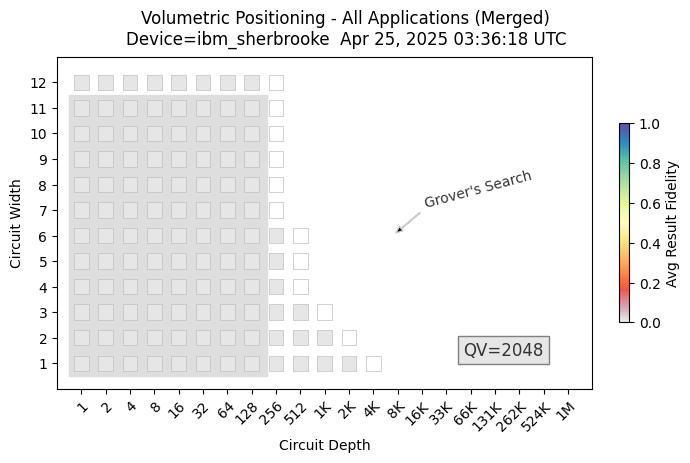

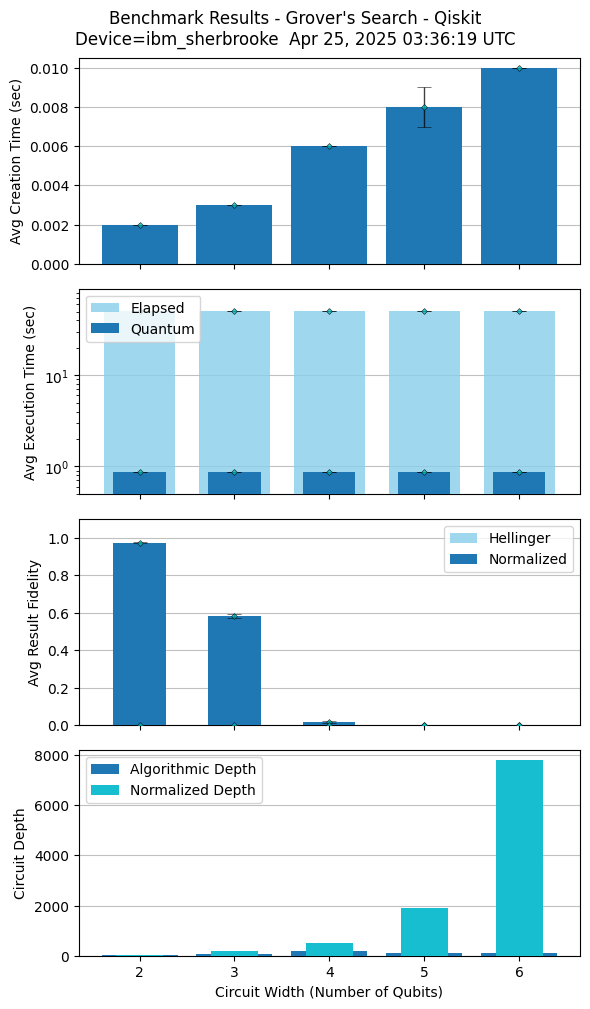

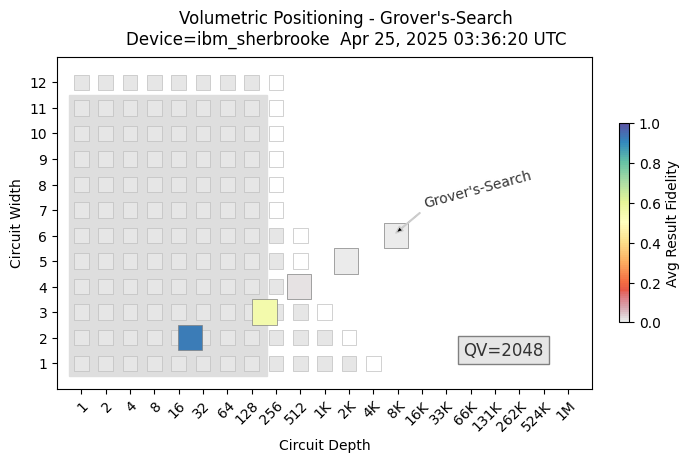


Plots potentially generated!
Check for image files like '_ALL-vplot-2*.png' and 'Benchmark Results - Grover's Search - Qiskit*.png'
Or check for inline plots.

Execution finished.


In [ ]:
# --- Imports ---
import sys
import time
import math
import numpy as np
import warnings
import os
import traceback
import json # Pour sauvegarder/charger les métriques

# Matplotlib pour les graphiques (requis par metrics.py)
import matplotlib.pyplot as plt

# --- 1) Se placer dans le dossier Grover ---
print(f"Répertoire courant AVANT changement: {os.getcwd()}")
try:
    base_path = "/content/QC-App-Oriented-Benchmarks"
    # *** Utiliser VOTRE nom de dossier 'grovers' ***
    target_dir = os.path.join(base_path, "grovers/qiskit")
    # ***********************************************
    if os.path.exists(target_dir):
        if os.getcwd() != os.path.abspath(target_dir):
             os.chdir(target_dir); print(f"Nouveau répertoire courant: {os.getcwd()}")
        else: print(f"Déjà dans le bon répertoire: {os.getcwd()}")
    else: print(f"ERREUR: Répertoire cible inexistant: {target_dir}"); sys.exit(1)
except Exception as e: print(f"Erreur changement de répertoire: {e}"); sys.exit(1)

# Qiskit imports
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit_ibm_runtime import QiskitRuntimeService, Sampler
from qiskit.compiler import transpile

# --- Importer les modules et fonctions du benchmark ---
try:
    import metrics as metrics
    # *** Importer depuis grovers_kernel ***
    from grovers_kernel import GroversSearch
    # *************************************
    from metrics import polarization_fidelity, finalize_group
    from metrics import plot_all_app_metrics, store_app_metrics # Utiliser ces fonctions
except ImportError as e:
    print(f"Erreur importation modules benchmark: {e}")
    print("Assurez-vous que 'grovers_kernel.py' et le dossier _common sont accessibles.")
    sys.exit(1)

# --- Configuration Qiskit Runtime ---
warnings.filterwarnings('ignore', category=DeprecationWarning)
try:
    # REMPLACEZ "VOTRE_TOKEN_API_ICI" SI NÉCESSAIRE
    service = QiskitRuntimeService( channel="ibm_quantum", instance="ibm-q/open/main", token="5fbbdfd71d575ba3bcc1a1fc39c96ec43556b3c5c4030bae8adb36345780c9f5bc622a0f07f6a48c7603db47d5dc61e01e4557bb49c07708811babe912d70147")
    backend = service.backend("ibm_sherbrooke")
    print(f"Using backend: {backend.name}"); print(f"Backend basis gates: {backend.basis_gates}")
except Exception as e: print(f"Erreur connexion IBM Quantum: {e}"); sys.exit(1)

# --- Initialisation des Métriques ---
metrics.init_metrics()
# Définir les informations nécessaires pour store_app_metrics et plot_all_app_metrics
metrics.circuit_metrics['subtitle'] = f"Device={backend.name}"
metrics.circuit_metrics['backend_id'] = backend.name
benchmark_name = "Grover's Search"; method = None; api_name = "Qiskit"
# Ce titre sera utilisé comme clé dans le fichier JSON et pour les graphiques
app_title = f"Benchmark Results - {benchmark_name} - {api_name}"

# --- Paramètres du Benchmark ---
min_qubits=2; max_qubits=6; skip_qubits=1; max_circuits=3; num_shots=1024
use_mcx_shim_in_kernel = False

# --- Boucle de Génération ---
circuits_info = []
print(f"\nGenerating circuits for {min_qubits} to {max_qubits} qubits ({benchmark_name})...")
generation_start_time = time.time(); metrics.start_time = generation_start_time # Nécessaire pour store_app_metrics
for num_qubits in range(min_qubits, max_qubits + 1, skip_qubits):
    input_size = num_qubits; print(f"... {num_qubits} qubits")
    num_circuits_for_size = min(2**input_size, max_circuits)
    np.random.seed(0)
    possible_s_ints = list(range(2**input_size))
    if len(possible_s_ints) <= num_circuits_for_size: s_range = possible_s_ints
    else: s_range = np.random.choice(possible_s_ints, size=num_circuits_for_size, replace=False)

    n_iterations = 1
    if num_qubits > 0: n_iterations = max(1, int(np.pi * np.sqrt(2 ** num_qubits) / 4))
    print(f"    (Using n_iterations = {n_iterations})")

    for s_int in s_range:
        s_int = int(s_int); ts = time.time()
        try:
            qc = GroversSearch(num_qubits, s_int, n_iterations, use_mcx_shim_in_kernel)
            if not isinstance(qc, QuantumCircuit): continue
            creation_time = time.time() - ts
        except Exception as e_gen: print(f"Erreur génération circuit Grover: {e_gen}"); continue

        metrics.store_metric(input_size, s_int, 'create_time', creation_time)
        qc_decomposed = qc.decompose()
        circuits_info.append({"circuit_decomposed": qc_decomposed, "num_qubits": num_qubits, "s_int": s_int})
print(f"\nGenerated {len(circuits_info)} circuits in {time.time() - generation_start_time:.2f}s.")

if not circuits_info: print("\nAucun circuit généré. Arrêt."); sys.exit(1)
all_circuits_decomposed = [info["circuit_decomposed"] for info in circuits_info]

# --- TRANSPILATION EXPLICITE ---
print(f"\nTranspiling {len(all_circuits_decomposed)} circuits for {backend.name}...")
transpilation_start_time = time.time(); transpiled_circuits = None
try:
    # *** MODIFIEZ LA VALEUR DE opt_level ICI ***
    opt_level = 2 # Essayez 2 ou 3 (au lieu de 1)
    # *******************************************
    print(f"Attempting transpilation with optimization_level={opt_level}...")
    transpiled_circuits = transpile(all_circuits_decomposed,
                                    backend=backend,
                                    optimization_level=opt_level) # Utilise la variable opt_level
    print(f"Transpilation finished in {time.time() - transpilation_start_time:.2f}s.")
except Exception as e: print(f"Erreur transpilation: {e}")

# --- Exécution avec Sampler ---
job = None; result = None; execution_finish_time = time.time()
if transpiled_circuits:
    print(f"\nSubmitting {len(transpiled_circuits)} transpiled circuits...")
    try:
        sampler = Sampler(mode=backend); submit_time = time.time()
        job = sampler.run(pubs=transpiled_circuits, shots=num_shots)
        print(f"Job submitted: {job.job_id()}"); print("Waiting for results...")
        result = job.result(); execution_finish_time = time.time()
        print(f"Job finished in {execution_finish_time - submit_time:.2f}s.")
    except Exception as e: print(f"Erreur exécution: {e}")

# --- Analyse des Résultats et Stockage (via appels à metrics.store_metric) ---
if result:
    print(f"\nAnalyzing {len(result)} results...")
    # Calcul temps quantique moyen
    total_quantum_time = None; avg_quantum_time = 0.0
    try:
        job_metrics = job.metrics(); total_quantum_time = job_metrics.get('usage', {}).get('quantum_seconds', None)
        if total_quantum_time:
             if len(result) > 0: avg_quantum_time = total_quantum_time / len(result)
             print(f"Total quantum execution time (reported by IBM): {total_quantum_time:.4f}s")
        else: print("Quantum execution time not available.")
    except Exception as e: print(f"Could not retrieve job metrics: {e}")

    for i, pub_result in enumerate(result):
        if i >= len(circuits_info) or i >= len(transpiled_circuits): continue
        info = circuits_info[i]; num_qubits = info["num_qubits"]; s_int = info["s_int"]
        circuit_decomposed = info["circuit_decomposed"]; transpiled_circuit = transpiled_circuits[i]
        try:
            # Extraire comptes
            if not pub_result.data: continue
            creg_keys = list(pub_result.data.keys());
            if not creg_keys: continue
            creg_name = creg_keys[0]; counts_data_bin = getattr(pub_result.data, creg_name)
            counts = counts_data_bin.get_counts()
            # Calcul Fidélité (Grover)
            fidelity_dict = {}; expected_key = format(s_int, f"0{num_qubits}b")
            correct_dist = {expected_key: 1.0}; fidelity_dict = polarization_fidelity(counts, correct_dist)
            fidelity_value = fidelity_dict.get('fidelity', 0.0)
            # Profondeurs et Temps
            depth_value = circuit_decomposed.depth(); transpiled_depth_value = transpiled_circuit.depth()
            quantum_time_value = avg_quantum_time
            # Stockage Métriques
            metrics.store_metric(num_qubits, s_int, 'fidelity', fidelity_value)
            metrics.store_metric(num_qubits, s_int, 'depth', depth_value)
            metrics.store_metric(num_qubits, s_int, 'tr_depth', transpiled_depth_value)
            if quantum_time_value > 0.0: metrics.store_metric(num_qubits, s_int, 'quantum_time', quantum_time_value)
            metrics.store_metric(num_qubits, s_int, 'elapsed_time', execution_finish_time - submit_time)
            if avg_quantum_time > 0.0: metrics.store_metric(num_qubits, s_int, 'exec_time', avg_quantum_time)
        except Exception as e: print(f"  Error analyzing result {i}: {e}")

    # --- Finaliser les groupes de métriques ---
    print("\nFinalizing metric groups (for internal state)...")
    processed_qubit_sizes = sorted(list(set(info["num_qubits"] for info in circuits_info)))
    for nq in processed_qubit_sizes:
        try: finalize_group(nq); metrics.report_metrics_for_group(str(nq))
        except Exception as e: print(f"  Error finalizing/reporting group for {nq} qubits: {e}")

    # --- Sauvegarder l'état interne du module metrics dans le fichier STANDARD ---
    print("\nStoring metrics state to file...")
    # Nom de fichier standard basé sur backend_id
    standard_data_filename = f"__data/DATA-{backend.name}.json"
    try:
        # On passe les variables globales du module metrics, en espérant qu'elles sont à jour
        circuit_metrics_to_save = metrics.circuit_metrics if hasattr(metrics, 'circuit_metrics') else {}
        group_metrics_to_save = metrics.group_metrics if hasattr(metrics, 'group_metrics') else {}
        start_time_to_save = metrics.start_time if hasattr(metrics, 'start_time') else generation_start_time
        end_time_to_save = time.time()

        # Utiliser store_app_metrics pour écrire dans le fichier standard
        store_app_metrics(backend.name, circuit_metrics_to_save, group_metrics_to_save, app_title,
                          start_time=start_time_to_save, end_time=end_time_to_save)
        print(f"Metrics stored in {standard_data_filename}")
    except Exception as e:
        print(f"Error storing metrics to file {standard_data_filename}: {e}")
        traceback.print_exc()

# --- Génération des Graphiques (en utilisant le fichier STANDARD sauvegardé) ---
print("\nGenerating plots from stored file data...")
try:
    # Appeler plot_all_app_metrics, qui chargera DATA-{backend.name}.json
    # Il contiendra maintenant les données de Grover (ayant écrasé QFT)
    plot_all_app_metrics(backend.name, do_all_plots=True, is_individual=True)
    print(f"\nPlots potentially generated!")
    print(f"Check for image files like '_ALL-vplot-2*.png' and '{app_title}*.png'")
    print("Or check for inline plots.")

except FileNotFoundError:
    print(f"\nErreur: Le fichier de données JSON 'DATA-{backend.name}.json' n'a pas été trouvé.")
except Exception as e:
    print(f"\nError generating plots from file: {e}")
    traceback.print_exc()

# --- Fin ---
warnings.filterwarnings('default', category=DeprecationWarning)
print("\nExecution finished.")

Répertoire courant AVANT changement: /content/QC-App-Oriented-Benchmarks/grovers/qiskit
Déjà dans le bon répertoire: /content/QC-App-Oriented-Benchmarks/grovers/qiskit
Using backend: ibm_sherbrooke
Backend basis gates: ['ecr', 'id', 'rz', 'sx', 'x']
... execution starting at Apr 25, 2025 03:51:06 UTC

Generating circuits for 2 to 6 qubits (Grover's Search)...
... 2 qubits
    (Using n_iterations = 1)
... 3 qubits
    (Using n_iterations = 2)
... 4 qubits
    (Using n_iterations = 3)
... 5 qubits
    (Using n_iterations = 4)
... 6 qubits
    (Using n_iterations = 6)

Generated 15 circuits in 0.15s.

Transpiling 15 circuits for ibm_sherbrooke...
Attempting transpilation with optimization_level=3...
Transpilation finished in 17.43s.

Submitting 15 transpiled circuits...
Job submitted: d05gdfxd8drg0083883g
Waiting for results...
Job finished in 26.62s.

Analyzing 15 results...
Total quantum execution time (reported by IBM): 10.0000s

Finalizing metric groups (for internal state)...
*******

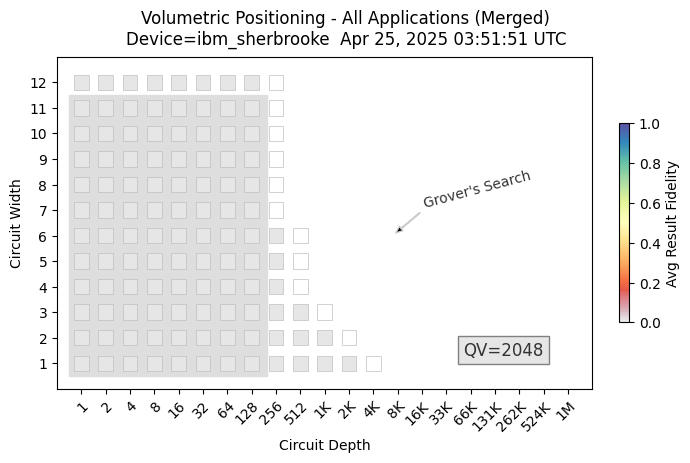

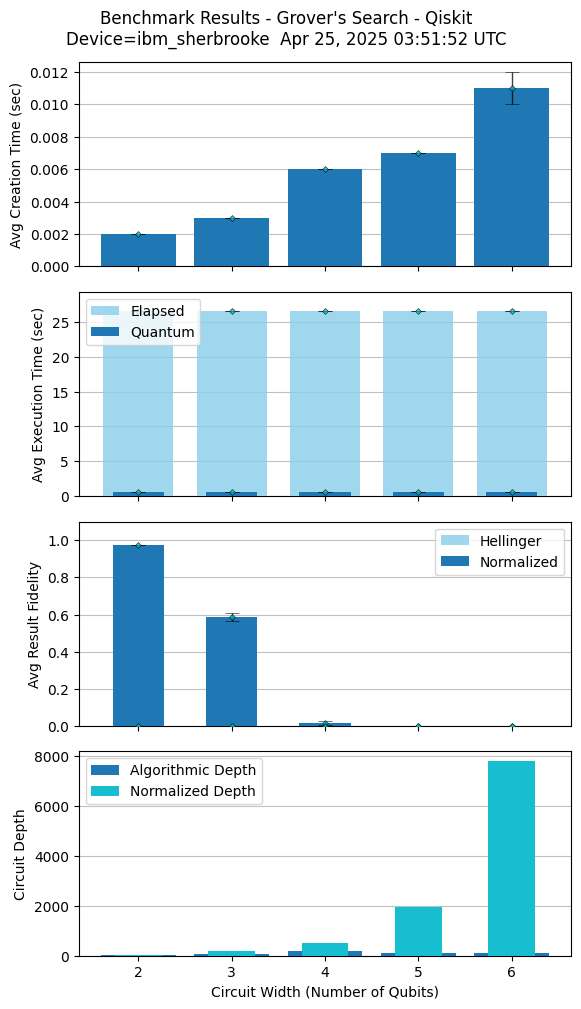

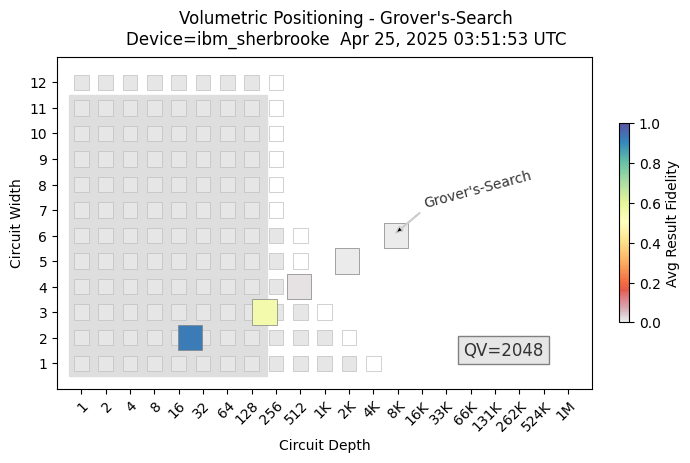


Plots potentially generated!
Check for image files like '_ALL-vplot-2*.png' and 'Benchmark Results - Grover's Search - Qiskit*.png'
Or check for inline plots.

Execution finished.


In [ ]:
# --- Imports ---
import sys
import time
import math
import numpy as np
import warnings
import os
import traceback
import json # Pour sauvegarder/charger les métriques

# Matplotlib pour les graphiques (requis par metrics.py)
import matplotlib.pyplot as plt

# --- 1) Se placer dans le dossier Grover ---
print(f"Répertoire courant AVANT changement: {os.getcwd()}")
try:
    base_path = "/content/QC-App-Oriented-Benchmarks"
    # *** Utiliser VOTRE nom de dossier 'grovers' ***
    target_dir = os.path.join(base_path, "grovers/qiskit")
    # ***********************************************
    if os.path.exists(target_dir):
        if os.getcwd() != os.path.abspath(target_dir):
             os.chdir(target_dir); print(f"Nouveau répertoire courant: {os.getcwd()}")
        else: print(f"Déjà dans le bon répertoire: {os.getcwd()}")
    else: print(f"ERREUR: Répertoire cible inexistant: {target_dir}"); sys.exit(1)
except Exception as e: print(f"Erreur changement de répertoire: {e}"); sys.exit(1)

# Qiskit imports
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit_ibm_runtime import QiskitRuntimeService, Sampler
from qiskit.compiler import transpile

# --- Importer les modules et fonctions du benchmark ---
try:
    import metrics as metrics
    # *** Importer depuis grovers_kernel ***
    from grovers_kernel import GroversSearch
    # *************************************
    from metrics import polarization_fidelity, finalize_group
    from metrics import plot_all_app_metrics, store_app_metrics # Utiliser ces fonctions
except ImportError as e:
    print(f"Erreur importation modules benchmark: {e}")
    print("Assurez-vous que 'grovers_kernel.py' et le dossier _common sont accessibles.")
    sys.exit(1)

# --- Configuration Qiskit Runtime ---
warnings.filterwarnings('ignore', category=DeprecationWarning)
try:
    # REMPLACEZ "VOTRE_TOKEN_API_ICI" SI NÉCESSAIRE
    service = QiskitRuntimeService( channel="ibm_quantum", instance="ibm-q/open/main", token="5fbbdfd71d575ba3bcc1a1fc39c96ec43556b3c5c4030bae8adb36345780c9f5bc622a0f07f6a48c7603db47d5dc61e01e4557bb49c07708811babe912d70147")
    backend = service.backend("ibm_sherbrooke")
    print(f"Using backend: {backend.name}"); print(f"Backend basis gates: {backend.basis_gates}")
except Exception as e: print(f"Erreur connexion IBM Quantum: {e}"); sys.exit(1)

# --- Initialisation des Métriques ---
metrics.init_metrics()
# Définir les informations nécessaires pour store_app_metrics et plot_all_app_metrics
metrics.circuit_metrics['subtitle'] = f"Device={backend.name}"
metrics.circuit_metrics['backend_id'] = backend.name
benchmark_name = "Grover's Search"; method = None; api_name = "Qiskit"
# Ce titre sera utilisé comme clé dans le fichier JSON et pour les graphiques
app_title = f"Benchmark Results - {benchmark_name} - {api_name}"

# --- Paramètres du Benchmark ---
min_qubits=2; max_qubits=6; skip_qubits=1; max_circuits=3; num_shots=1024
use_mcx_shim_in_kernel = False

# --- Boucle de Génération ---
circuits_info = []
print(f"\nGenerating circuits for {min_qubits} to {max_qubits} qubits ({benchmark_name})...")
generation_start_time = time.time(); metrics.start_time = generation_start_time # Nécessaire pour store_app_metrics
for num_qubits in range(min_qubits, max_qubits + 1, skip_qubits):
    input_size = num_qubits; print(f"... {num_qubits} qubits")
    num_circuits_for_size = min(2**input_size, max_circuits)
    np.random.seed(0)
    possible_s_ints = list(range(2**input_size))
    if len(possible_s_ints) <= num_circuits_for_size: s_range = possible_s_ints
    else: s_range = np.random.choice(possible_s_ints, size=num_circuits_for_size, replace=False)

    n_iterations = 1
    if num_qubits > 0: n_iterations = max(1, int(np.pi * np.sqrt(2 ** num_qubits) / 4))
    print(f"    (Using n_iterations = {n_iterations})")

    for s_int in s_range:
        s_int = int(s_int); ts = time.time()
        try:
            qc = GroversSearch(num_qubits, s_int, n_iterations, use_mcx_shim_in_kernel)
            if not isinstance(qc, QuantumCircuit): continue
            creation_time = time.time() - ts
        except Exception as e_gen: print(f"Erreur génération circuit Grover: {e_gen}"); continue

        metrics.store_metric(input_size, s_int, 'create_time', creation_time)
        qc_decomposed = qc.decompose()
        circuits_info.append({"circuit_decomposed": qc_decomposed, "num_qubits": num_qubits, "s_int": s_int})
print(f"\nGenerated {len(circuits_info)} circuits in {time.time() - generation_start_time:.2f}s.")

if not circuits_info: print("\nAucun circuit généré. Arrêt."); sys.exit(1)
all_circuits_decomposed = [info["circuit_decomposed"] for info in circuits_info]

# --- TRANSPILATION EXPLICITE ---
print(f"\nTranspiling {len(all_circuits_decomposed)} circuits for {backend.name}...")
transpilation_start_time = time.time(); transpiled_circuits = None
try:
    # *** MODIFIEZ LA VALEUR DE opt_level ICI ***
    opt_level = 3 # Essayez 2 ou 3 (au lieu de 1)
    # *******************************************
    print(f"Attempting transpilation with optimization_level={opt_level}...")
    transpiled_circuits = transpile(all_circuits_decomposed,
                                    backend=backend,
                                    optimization_level=opt_level) # Utilise la variable opt_level
    print(f"Transpilation finished in {time.time() - transpilation_start_time:.2f}s.")
except Exception as e: print(f"Erreur transpilation: {e}")

# --- Exécution avec Sampler ---
job = None; result = None; execution_finish_time = time.time()
if transpiled_circuits:
    print(f"\nSubmitting {len(transpiled_circuits)} transpiled circuits...")
    try:
        sampler = Sampler(mode=backend); submit_time = time.time()
        job = sampler.run(pubs=transpiled_circuits, shots=num_shots)
        print(f"Job submitted: {job.job_id()}"); print("Waiting for results...")
        result = job.result(); execution_finish_time = time.time()
        print(f"Job finished in {execution_finish_time - submit_time:.2f}s.")
    except Exception as e: print(f"Erreur exécution: {e}")

# --- Analyse des Résultats et Stockage (via appels à metrics.store_metric) ---
if result:
    print(f"\nAnalyzing {len(result)} results...")
    # Calcul temps quantique moyen
    total_quantum_time = None; avg_quantum_time = 0.0
    try:
        job_metrics = job.metrics(); total_quantum_time = job_metrics.get('usage', {}).get('quantum_seconds', None)
        if total_quantum_time:
             if len(result) > 0: avg_quantum_time = total_quantum_time / len(result)
             print(f"Total quantum execution time (reported by IBM): {total_quantum_time:.4f}s")
        else: print("Quantum execution time not available.")
    except Exception as e: print(f"Could not retrieve job metrics: {e}")

    for i, pub_result in enumerate(result):
        if i >= len(circuits_info) or i >= len(transpiled_circuits): continue
        info = circuits_info[i]; num_qubits = info["num_qubits"]; s_int = info["s_int"]
        circuit_decomposed = info["circuit_decomposed"]; transpiled_circuit = transpiled_circuits[i]
        try:
            # Extraire comptes
            if not pub_result.data: continue
            creg_keys = list(pub_result.data.keys());
            if not creg_keys: continue
            creg_name = creg_keys[0]; counts_data_bin = getattr(pub_result.data, creg_name)
            counts = counts_data_bin.get_counts()
            # Calcul Fidélité (Grover)
            fidelity_dict = {}; expected_key = format(s_int, f"0{num_qubits}b")
            correct_dist = {expected_key: 1.0}; fidelity_dict = polarization_fidelity(counts, correct_dist)
            fidelity_value = fidelity_dict.get('fidelity', 0.0)
            # Profondeurs et Temps
            depth_value = circuit_decomposed.depth(); transpiled_depth_value = transpiled_circuit.depth()
            quantum_time_value = avg_quantum_time
            # Stockage Métriques
            metrics.store_metric(num_qubits, s_int, 'fidelity', fidelity_value)
            metrics.store_metric(num_qubits, s_int, 'depth', depth_value)
            metrics.store_metric(num_qubits, s_int, 'tr_depth', transpiled_depth_value)
            if quantum_time_value > 0.0: metrics.store_metric(num_qubits, s_int, 'quantum_time', quantum_time_value)
            metrics.store_metric(num_qubits, s_int, 'elapsed_time', execution_finish_time - submit_time)
            if avg_quantum_time > 0.0: metrics.store_metric(num_qubits, s_int, 'exec_time', avg_quantum_time)
        except Exception as e: print(f"  Error analyzing result {i}: {e}")

    # --- Finaliser les groupes de métriques ---
    print("\nFinalizing metric groups (for internal state)...")
    processed_qubit_sizes = sorted(list(set(info["num_qubits"] for info in circuits_info)))
    for nq in processed_qubit_sizes:
        try: finalize_group(nq); metrics.report_metrics_for_group(str(nq))
        except Exception as e: print(f"  Error finalizing/reporting group for {nq} qubits: {e}")

    # --- Sauvegarder l'état interne du module metrics dans le fichier STANDARD ---
    print("\nStoring metrics state to file...")
    # Nom de fichier standard basé sur backend_id
    standard_data_filename = f"__data/DATA-{backend.name}.json"
    try:
        # On passe les variables globales du module metrics, en espérant qu'elles sont à jour
        circuit_metrics_to_save = metrics.circuit_metrics if hasattr(metrics, 'circuit_metrics') else {}
        group_metrics_to_save = metrics.group_metrics if hasattr(metrics, 'group_metrics') else {}
        start_time_to_save = metrics.start_time if hasattr(metrics, 'start_time') else generation_start_time
        end_time_to_save = time.time()

        # Utiliser store_app_metrics pour écrire dans le fichier standard
        store_app_metrics(backend.name, circuit_metrics_to_save, group_metrics_to_save, app_title,
                          start_time=start_time_to_save, end_time=end_time_to_save)
        print(f"Metrics stored in {standard_data_filename}")
    except Exception as e:
        print(f"Error storing metrics to file {standard_data_filename}: {e}")
        traceback.print_exc()

# --- Génération des Graphiques (en utilisant le fichier STANDARD sauvegardé) ---
print("\nGenerating plots from stored file data...")
try:
    # Appeler plot_all_app_metrics, qui chargera DATA-{backend.name}.json
    # Il contiendra maintenant les données de Grover (ayant écrasé QFT)
    plot_all_app_metrics(backend.name, do_all_plots=True, is_individual=True)
    print(f"\nPlots potentially generated!")
    print(f"Check for image files like '_ALL-vplot-2*.png' and '{app_title}*.png'")
    print("Or check for inline plots.")

except FileNotFoundError:
    print(f"\nErreur: Le fichier de données JSON 'DATA-{backend.name}.json' n'a pas été trouvé.")
except Exception as e:
    print(f"\nError generating plots from file: {e}")
    traceback.print_exc()

# --- Fin ---
warnings.filterwarnings('default', category=DeprecationWarning)
print("\nExecution finished.")